# <u><b>Online Shoppers Purchasing Intention Analysis</u></b>

#### <u><b>Project Objective<u><b>
The primary objective of this project is to develop a machine learning classification model that predicts whether an online visitor will generate revenue (purchase) during a browsing session. 

The model is trained using customer browsing behavior, page interaction metrics, visitor information, and session details. 

Multiple machine learning models and preprocessing techniques are compared to identify the model that provides the best predictive performance and generalization ability.

#### <u><b>Problem Statement</u></b>

E-commerce businesses often struggle to understand why some users purchase products while others leave the website without converting.

The goal of this project is to build a machine learning model that predicts whether a visitor is likely to make a purchase based on their browsing behavior, session characteristics, and website interaction data. 

Accurate predictions can help businesses target high-intent customers with personalized offers, improve conversion rates, and optimize marketing strategies..


#### <u><b>Dataset Description</u></b>

The dataset contains website session-level data where each row represents a single customer session. It consists of 12,330 sessions and 18 features.

It includes:
- User behavior data (page visits, duration)
- Website interaction metrics (bounce rate, exit rate)
- User information (visitor type, region)
- Target variable: Revenue (indicates whether purchase was made)


#### <u><b>Business Objectives</u></b>

The business objective is to identify visitors with a high probability of making a purchase so that marketing teams can deliver personalized recommendations, targeted promotions, and timely interventions. 

This helps increase conversion rates, improve customer engagement, reduce marketing costs, and maximize revenue.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
pd.set_option('display.float_format', lambda x: '%.5f' % x)
np.set_printoptions(suppress=True)

In [68]:
df=pd.read_csv(r"C:\Users\acer\Downloads\online_shoppers_intention.csv")

In [69]:
df.head()  

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.00000,0,0.00000,2,64.00000,0.00000,0.10000,0.00000,0.00000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.00000,0,0.00000,2,2.66667,0.05000,0.14000,0.00000,0.00000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.00000,0,0.00000,10,627.50000,0.02000,0.05000,0.00000,0.00000,Feb,3,3,1,4,Returning_Visitor,True,False


In [70]:
df.shape

(12330, 18)

In [71]:
df.size

221940

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [73]:
df.duplicated().sum() # check duplicates

np.int64(125)

In [74]:
duplicates = df[df.duplicated(keep=False)] #Check for duplicate rows -original rows & repeated rows
print(duplicates.shape)
duplicates.head(20)

(201, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,3,2,3,3,Returning_Visitor,False,False
252,0,0.00000,0,0.00000,2,0.00000,0.20000,0.20000,0.00000,0.00000,Mar,1,1,1,1,Returning_Visitor,False,False
286,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Mar,2,2,1,1,Returning_Visitor,False,False
293,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Mar,1,1,1,1,Returning_Visitor,True,False
298,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Mar,1,1,8,1,Returning_Visitor,False,False
330,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Mar,3,2,3,1,Returning_Visitor,False,False


In [75]:
# Sort and inspect duplicate pairs side by side
duplicates.sort_values(by=list(df.columns)).head(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,4,1,Returning_Visitor,True,False


In [76]:
# Exact duplicates (all 18 columns same) vs Partial duplicates (same Month, VisitorType, Browser, Region)

print("Exact duplicates:", df.duplicated().sum())         
print("Partial duplicates:", df.duplicated(subset=['Month','VisitorType','Browser','Region']).sum())

Exact duplicates: 125
Partial duplicates: 11490


In [77]:
# All 18 columns are identical including float columns like ProductRelated_Duration = 0.00000 (exactly same in both rows) 
# and BounceRates = ExitRates = 0.20000 (perfectly round, identical)
# Real users CANNOT produce identical float values across all metrics
# These rows are statistically impossible to be genuine sessions
# Confirmed as data collection/logging errors-- removed

# Partial duplicates (11,490) are genuine users sharing same Month/Browser/Region 
# and their PageValues, Duration, BounceRates are all DIFFERENT--retained
df.drop_duplicates(inplace=True)
print("Clean dataset shape:", df.shape) 

Clean dataset shape: (12205, 18)


In [78]:
df.isnull().sum()    # check missing values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [79]:
df["Revenue"] = df["Revenue"].astype(int)    #0=false #1=true #change dtypes
df["Weekend"] = df["Weekend"].astype(int)

In [80]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                      int64
Revenue                      int64
dtype: object

In [81]:
df["Month"] = df["Month"].replace("June", "Jun")     #Fix Month Inconsistency

In [82]:
df['Month'].unique()

array(['Feb', 'Mar', 'May', 'Oct', 'Jun', 'Jul', 'Aug', 'Nov', 'Sep',
       'Dec'], dtype=object)

In [83]:
df.select_dtypes(include='number').lt(0).sum() # no negative values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
Weekend                    0
Revenue                    0
dtype: int64

##### I validated BounceRate and ExitRate ranges and found no invalid values, indicating good data consistency and quality.”

In [84]:
df[(df['BounceRates'] > 1) | (df['BounceRates'] < 0)]    #found no invalid values

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue


In [85]:
df[(df['ExitRates'] > 1) | (df['ExitRates'] < 0)]     #found no invalid values

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue


In [86]:
df['TotalPages'] = (
    df['Administrative']
    + df['Informational']
    + df['ProductRelated']
)

df['TotalDuration'] = (
    df['Administrative_Duration']
    + df['Informational_Duration']
    + df['ProductRelated_Duration']
)

In [87]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,TotalPages,TotalDuration
0,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,1,1,1,1,Returning_Visitor,0,0,1,0.00000
1,0,0.00000,0,0.00000,2,64.00000,0.00000,0.10000,0.00000,0.00000,Feb,2,2,1,2,Returning_Visitor,0,0,2,64.00000
2,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,4,1,9,3,Returning_Visitor,0,0,1,0.00000
3,0,0.00000,0,0.00000,2,2.66667,0.05000,0.14000,0.00000,0.00000,Feb,3,2,2,4,Returning_Visitor,0,0,2,2.66667
4,0,0.00000,0,0.00000,10,627.50000,0.02000,0.05000,0.00000,0.00000,Feb,3,3,1,4,Returning_Visitor,1,0,10,627.50000


# <u><b>EDA (Exploratory Data Analysis)</u></b>

## <u><b>UNIVARIATE ANALYSIS</u></b> (Cat , Num)

#### I separated columns based on business meaning rather than datatype alone. 
Features like "OperatingSystems", "Browser", "Region", "TrafficType", "Weekend" columns are stored as int but always treated as categorical because they are just ID codes/labels, not measurements.


##### Categorical Variables (Cat)

In [88]:
cat_columns = [
    'Month',
    'VisitorType',
    'Weekend',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType'
]

##### Numerical Variables (Num)

In [89]:
num_columns = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'TotalPages',
    'TotalDuration',
    'Revenue'
]

# <u><b>1. EDA of Cat columns</u></b>

### <b>Frequency Count Distribution of Categorical Variables</b>

In [90]:
for col in cat_columns:
    
    print("\n" + "="*44)
    print(f"Percentage Distribution of {col}")
    print("="*44)
    
    display(
        round(df[col].value_counts()*100, 2)
    )


Percentage Distribution of Month


Month
May    332900
Nov    298200
Mar    186000
Dec    170600
Oct     54900
Sep     44800
Aug     43300
Jul     43200
Jun     28500
Feb     18100
Name: count, dtype: int64


Percentage Distribution of VisitorType


VisitorType
Returning_Visitor    1043100
New_Visitor           169300
Other                   8100
Name: count, dtype: int64


Percentage Distribution of Weekend


...

Browser
2     788300
1     242700
4      73100
5      46500
6      17400
10     16300
8      13500
3      10500
13      5600
7       4900
12      1000
11       600
9        100
Name: count, dtype: int64


Percentage Distribution of Region


Region
1    471400
3    237900
4    117100
2    112800
6     80100
7     75800
9     50500
8     43100
5     31800
Name: count, dtype: int64


Percentage Distribution of TrafficType


TrafficType
2     391100
1     238800
3     201300
4     106600
13     72800
10     45000
6      44300
8      34300
5      26000
11     24700
20     19300
9       4100
7       4000
15      3700
19      1700
14      1300
18      1000
16       300
12       100
17       100
Name: count, dtype: int64

### <b>Unique Value Analysis of Categorical Variables</b>

In [91]:
for col in cat_columns:            
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())


Month (10 unique values):
['Feb' 'Mar' 'May' 'Oct' 'Jun' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType (3 unique values):
['Returning_Visitor' 'New_Visitor' 'Other']

Weekend (2 unique values):
[0 1]

OperatingSystems (8 unique values):
[1 2 4 3 7 6 8 5]

Browser (13 unique values):
[ 1  2  3  4  5  6  7 10  8  9 12 13 11]

Region (9 unique values):
[1 9 2 3 4 5 6 7 8]

TrafficType (20 unique values):
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 16 17 20]


### <b>Summary Table for all Categorical Variables</b>

In [92]:
summary = []                            
for col in cat_columns:
    summary.append({
        "Column": col,
        "Unique Values": df[col].nunique(),
        "Top Category": df[col].value_counts().idxmax(),
        "Top Category %": round(df[col].value_counts(normalize=True).max()*100,2)
    })

pd.DataFrame(summary)

,Column,Unique Values,Top Category,Top Category %
0,Month,10,May,27.28000
1,VisitorType,3,Returning_Visitor,85.46000
2,Weekend,2,0,76.58000
3,OperatingSystems,8,2,53.59000
4,Browser,13,2,64.59000
5,Region,9,1,38.62000
6,TrafficType,20,2,32.04000


### <b>Count Distribution of all Categorical Variables</b>

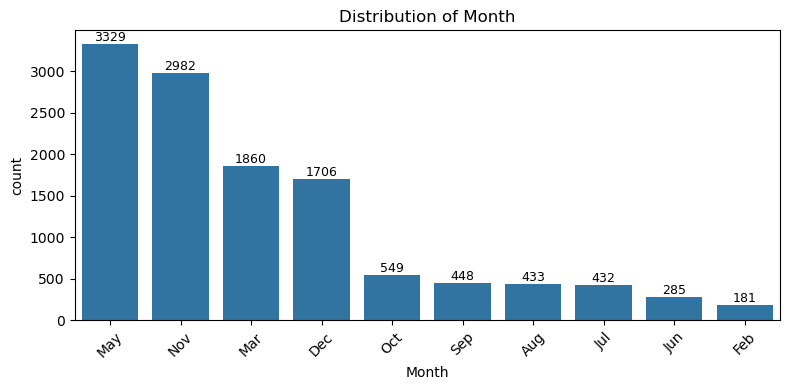

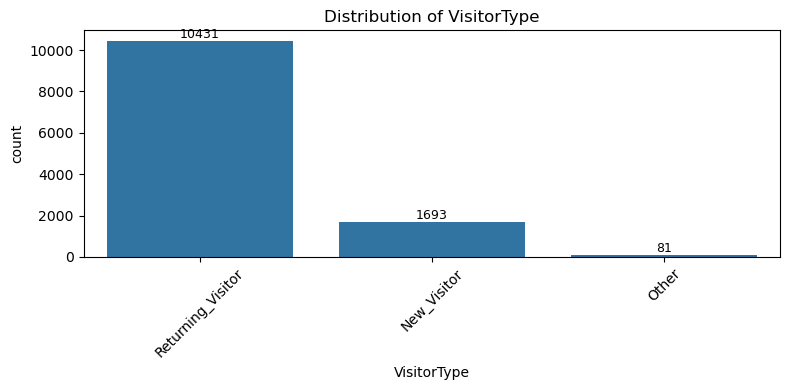

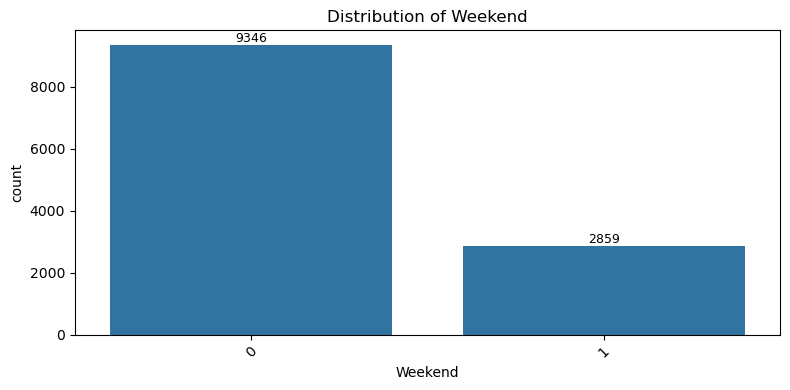

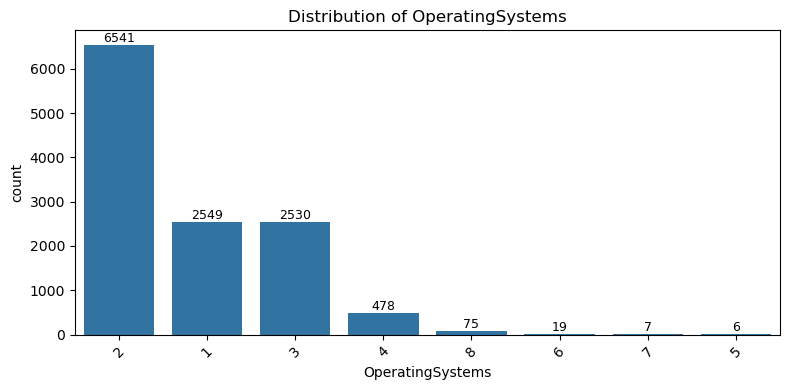

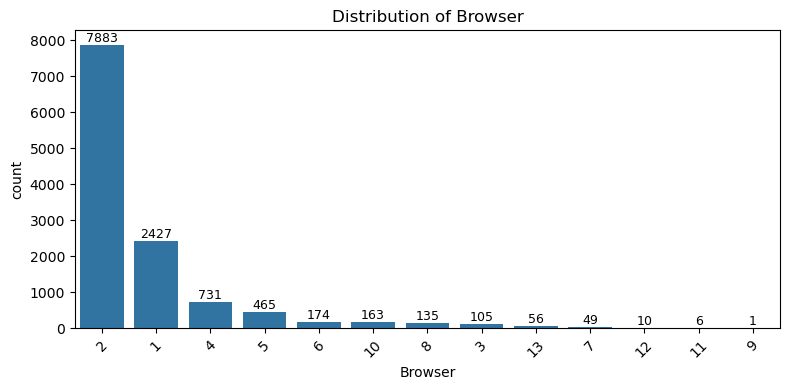

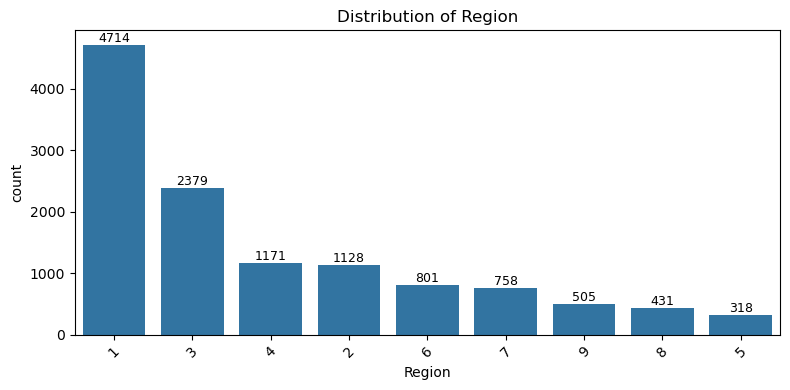

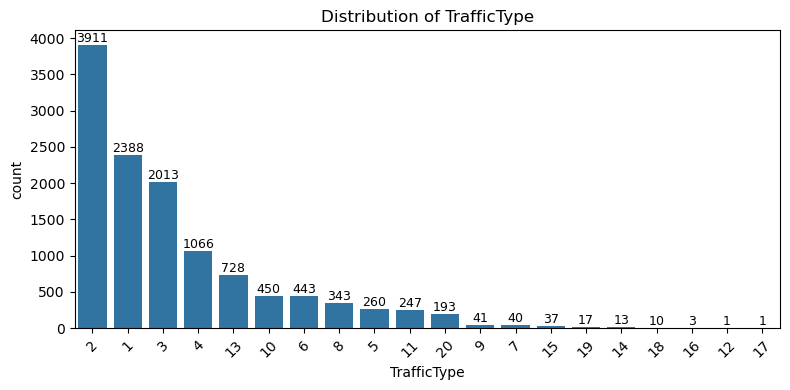

In [93]:
for col in cat_columns:
    plt.figure(figsize=(8,4))
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}', 
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', 
            va='bottom',
            fontsize=9)
    
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## <u><b> 2. EDA of Num_columns</u></b>

In [94]:
df[num_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.00000,2.33888,3.33044,0.00000,0.00000,1.00000,4.00000,27.00000
Administrative_Duration,12205.00000,81.64633,177.49185,0.00000,0.00000,9.00000,94.70000,3398.75000
Informational,12205.00000,0.50873,1.27562,0.00000,0.00000,0.00000,0.00000,24.00000
Informational_Duration,12205.00000,34.82545,141.42481,0.00000,0.00000,0.00000,0.00000,2549.37500
ProductRelated,12205.00000,32.04564,44.59365,0.00000,8.00000,18.00000,38.00000,705.00000
ProductRelated_Duration,12205.00000,1206.98246,1919.60140,0.00000,193.00000,608.94286,1477.15476,63973.52223
BounceRates,12205.00000,0.02037,0.04526,0.00000,0.00000,0.00290,0.01667,0.20000
ExitRates,12205.00000,0.04147,0.04616,0.00000,0.01423,0.02500,0.04853,0.20000
PageValues,12205.00000,5.94957,18.65367,0.00000,0.00000,0.00000,0.00000,361.76374
SpecialDay,12205.00000,0.06194,0.19967,0.00000,0.00000,0.00000,0.00000,1.00000


### <b>Distribution (Histogram + Boxplot) for all Numerical Variables</b>

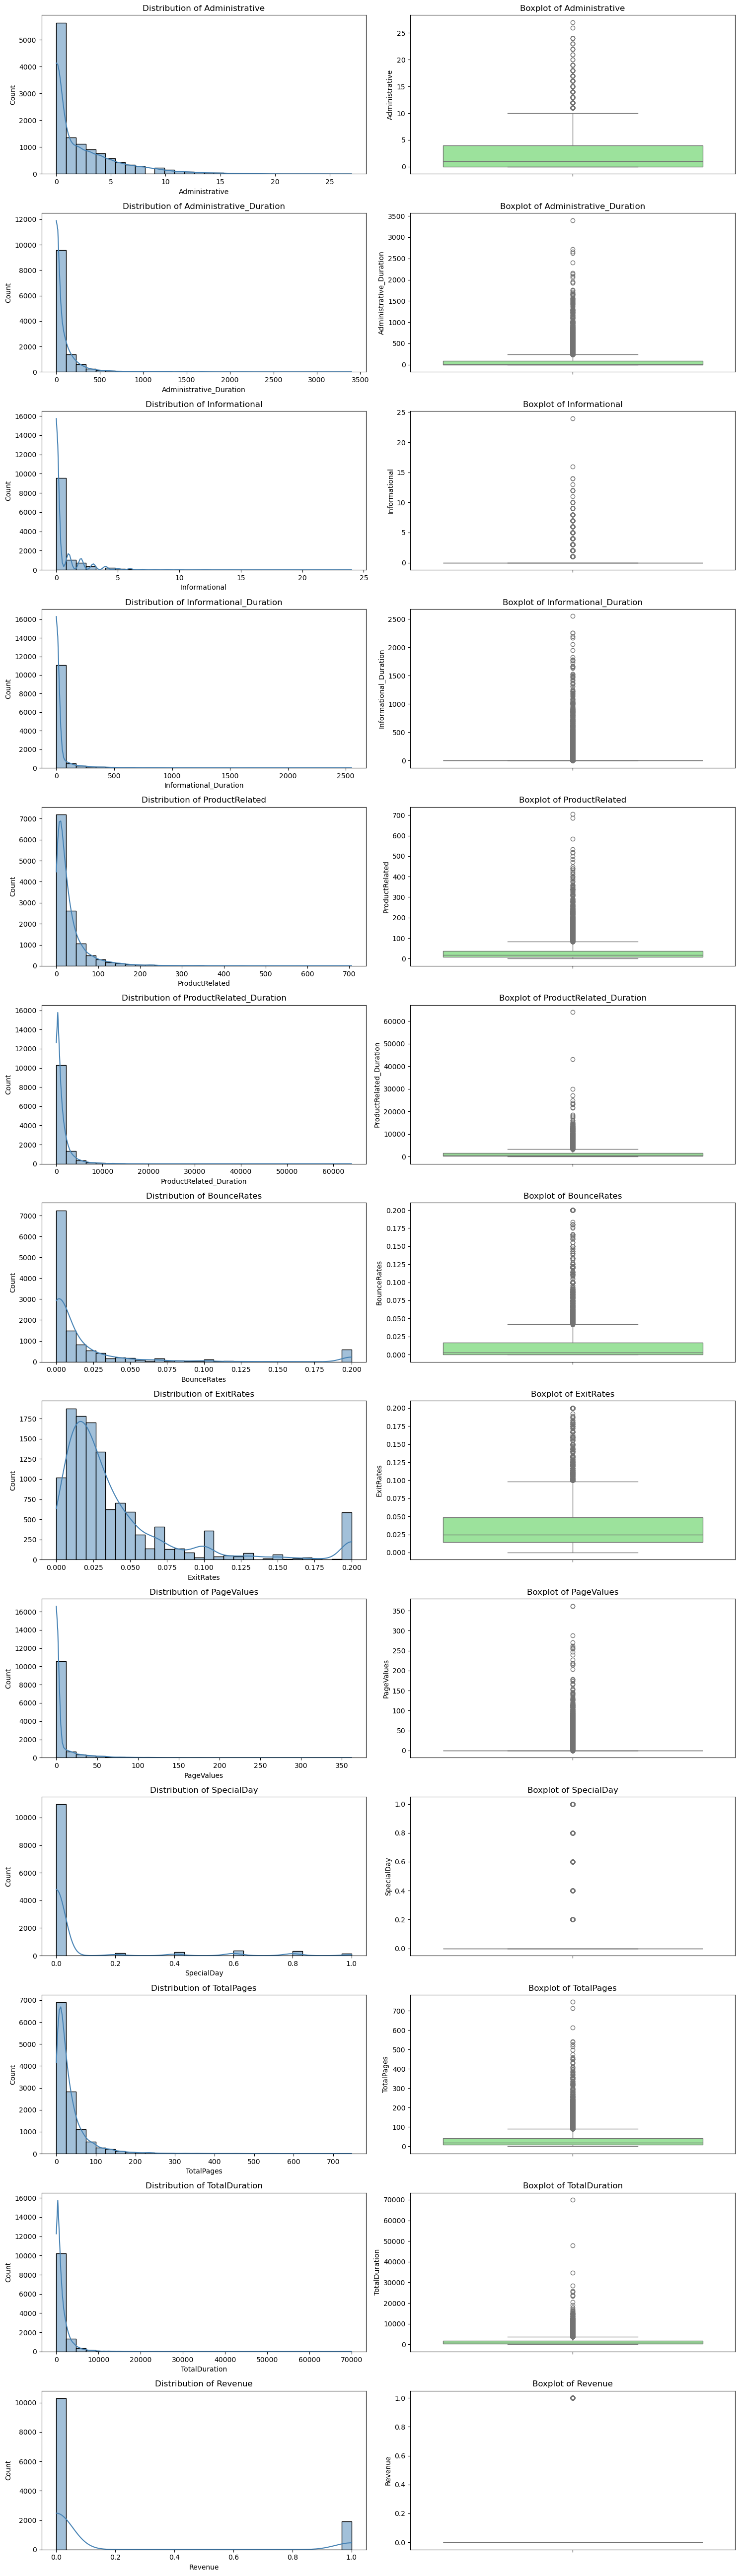

In [95]:
fig, axes = plt.subplots(len(num_columns), 2, figsize=(15, len(num_columns) * 4))

for i, col in enumerate(num_columns):
    
    #Histogram  → shows distribution shape and skewness
    sns.histplot(df[col], bins=30, kde=True, color="steelblue", ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribution of {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")

    #Boxplot  → shows spread, median and outliers
    sns.boxplot(data=df, y=col, color="lightgreen", ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot of {col}")
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()


In [96]:
df['SpecialDay'].value_counts()

SpecialDay
0.00000    10956
0.60000      350
0.80000      324
0.40000      243
0.20000      178
1.00000      154
Name: count, dtype: int64

## <b><u>KEY FINDING SUMMARY<b><u>

- **Product pages dominate engagement**  
Users spend 1,206 seconds on average there, dwarfing all other page types. That's where the entire conversion opportunity lives.
  
- **Returning visitors are 77% of traffic**   
The site has a massive loyal base that barely converts. Even a small improvement here = big revenue impact.

- **PageValues are near-zero for most sessions**  
Almost all sessions don't contribute revenue at all. Revenue is generated by a tiny fraction of sessions with very high page values. The overall conversion rate sits at just 15.63%.

- **May & November are the only high-traffic months**  
These two months alone dominate overall traffic

# <u><b>BIVARIATE ANALYSIS</u></b> (Num-Num, Cat-Cat, Num-Cat)

## <u><b>NUM-NUM ANALYSIS</u></b>

In [97]:
df[num_columns].corr() # corelation  

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,TotalPages,TotalDuration,Revenue
Administrative,1.00000,0.60046,0.37526,0.25481,0.42830,0.37115,-0.21310,-0.31125,0.09702,-0.09695,0.49132,0.41836,0.13633
Administrative_Duration,0.60046,1.00000,0.30142,0.23721,0.28686,0.35358,-0.13691,-0.20197,0.06623,-0.07467,0.32549,0.43534,0.09177
Informational,0.37526,0.30142,1.00000,0.61865,0.37257,0.38605,-0.10910,-0.15943,0.04741,-0.04935,0.41048,0.43156,0.09363
Informational_Duration,0.25481,0.23721,0.61865,1.00000,0.27908,0.34660,-0.06988,-0.10285,0.03009,-0.03126,0.30204,0.41532,0.06936
ProductRelated,0.42830,0.28686,0.37257,0.27908,1.00000,0.86033,-0.19288,-0.28608,0.05420,-0.02584,0.99717,0.85224,0.15604
ProductRelated_Duration,0.37115,0.35358,0.38605,0.34660,0.86033,1.00000,-0.17383,-0.24527,0.05092,-0.03812,0.85988,0.99389,0.15008
BounceRates,-0.21310,-0.13691,-0.10910,-0.06988,-0.19288,-0.17383,1.00000,0.90214,-0.11580,0.08863,-0.20268,-0.17998,-0.14509
ExitRates,-0.31125,-0.20197,-0.15943,-0.10285,-0.28608,-0.24527,0.90214,1.00000,-0.17363,0.11718,-0.30020,-0.25501,-0.20432
PageValues,0.09702,0.06623,0.04741,0.03009,0.05420,0.05092,-0.11580,-0.17363,1.00000,-0.06448,0.06006,0.05566,0.49189
SpecialDay,-0.09695,-0.07467,-0.04935,-0.03126,-0.02584,-0.03812,0.08863,0.11718,-0.06448,1.00000,-0.03299,-0.04445,-0.08360


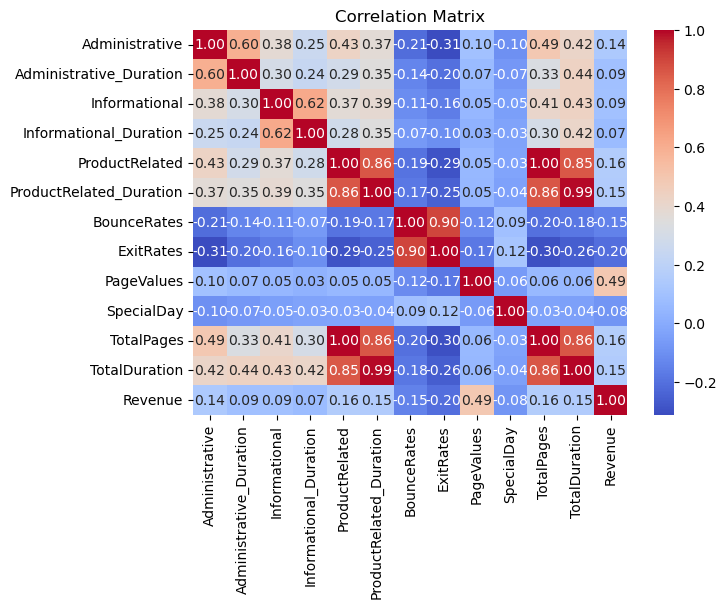

In [98]:
plt.figure(figsize=(7,5))
sns.heatmap(df[num_columns].corr(), 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

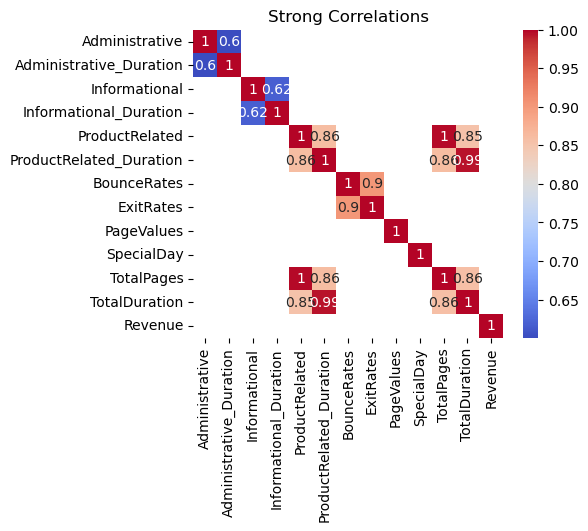

In [99]:
corr = df[num_columns].corr()

# strong correlations 
strong_corr = corr[(corr > 0.5) | (corr < -0.5)]

plt.figure(figsize=(5,4))
sns.heatmap(strong_corr, annot=True, cmap='coolwarm')
plt.title("Strong Correlations")
plt.show()


#### I selected below visualizations based not only on correlation strength but also on business relevance and impact on customer behavior and revenue.”


## <u><b>BounceRates vs ExitRates</u></b> 
#### [Correlation = 0.90 (Very Strong Positive Correlation)]

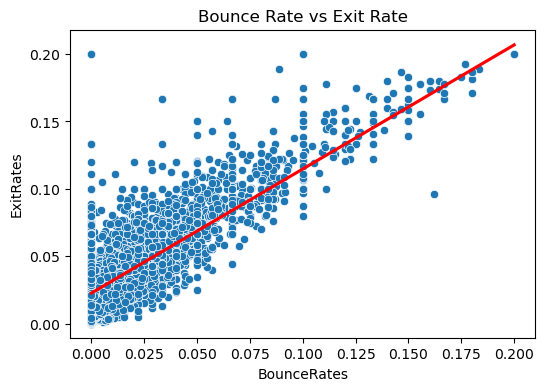

In [100]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='BounceRates',
                y='ExitRates',
                data=df)
sns.regplot(x='BounceRates',
            y='ExitRates',
            data=df,
            scatter=False, color='red')
plt.title('Bounce Rate vs Exit Rate')
plt.xlabel('BounceRates')
plt.ylabel('ExitRates')
plt.show()

## <u><b>ProductRelated vs ProductRelated_Duration</u></b>
#### [Correlation = 0.86 (Strong Positive Correlation)]


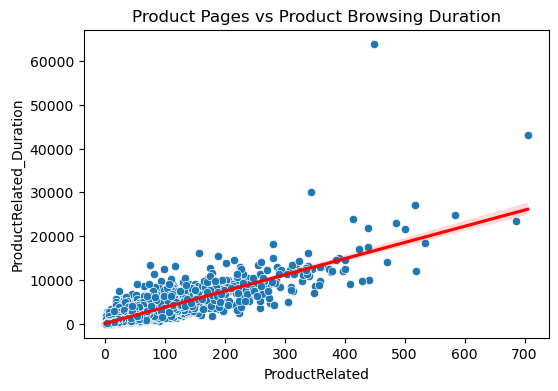

In [101]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='ProductRelated',
                y='ProductRelated_Duration',
                data=df)
sns.regplot(x='ProductRelated',
            y='ProductRelated_Duration',
            data=df,
            scatter=False, color='red')
plt.title('Product Pages vs Product Browsing Duration')
plt.xlabel('ProductRelated')
plt.ylabel('ProductRelated_Duration')
plt.show()

## <u><b>PageValues vs Revenue</u></b>

<Axes: xlabel='Revenue', ylabel='PageValues'>

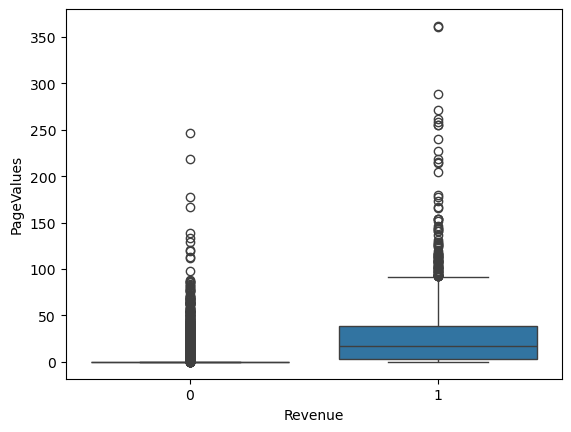

In [102]:
sns.boxplot(x='Revenue', y='PageValues', data=df)

## <u><b>ProductRelated vs Revenue</u></b>

<Axes: xlabel='Revenue', ylabel='ProductRelated'>

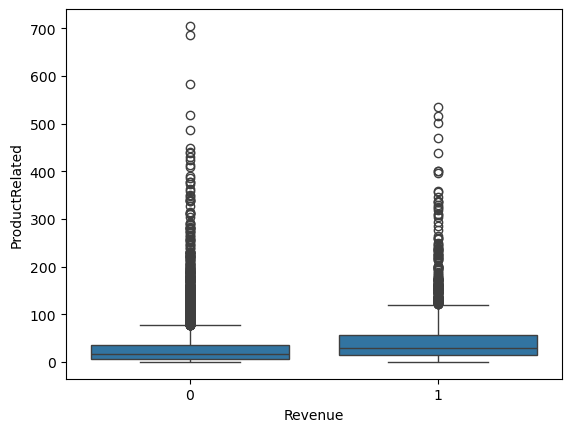

In [103]:
sns.boxplot(x='Revenue', y='ProductRelated', data=df)

## <u><b>ExitRates vs Revenue</u></b>

<Axes: xlabel='Revenue', ylabel='ExitRates'>

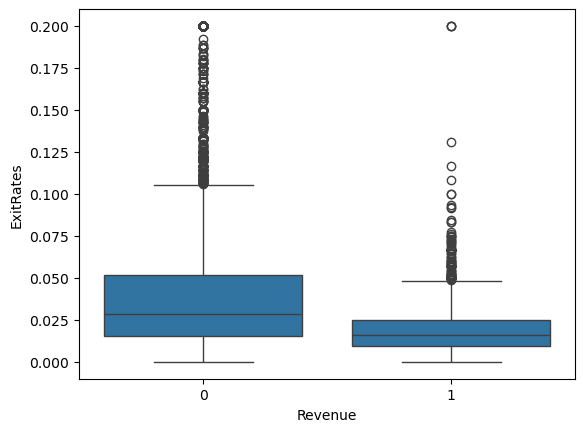

In [104]:
sns.boxplot(x='Revenue', y='ExitRates', data=df)

## <u><b>BounceRates vs Revenue</u></b>

<Axes: xlabel='Revenue', ylabel='BounceRates'>

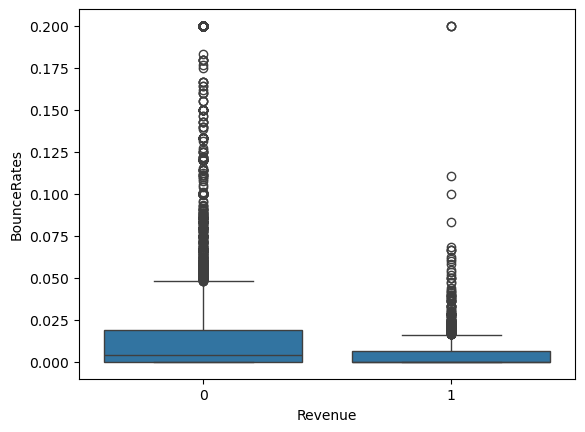

In [105]:
sns.boxplot(x='Revenue', y='BounceRates', data=df)

# <u><b> CAT-CAT ANALYSIS</u></b>

## <u><b>Weekend vs VisitorType</u></b>

VisitorType,New_Visitor,Other,Returning_Visitor
Weekend,,,
0,1214,74,8058
1,479,7,2373


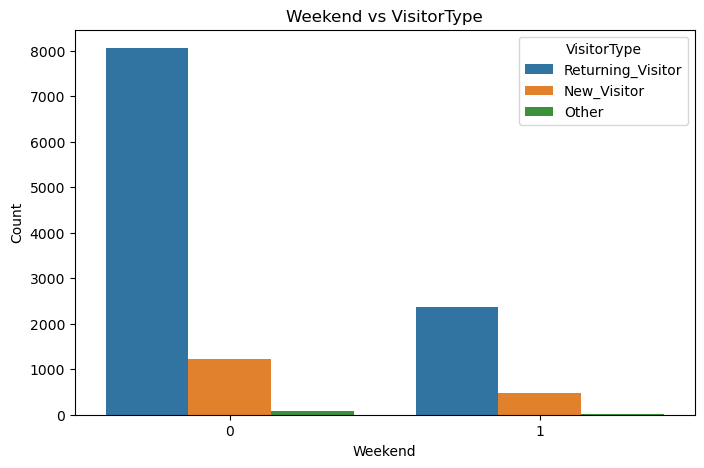

In [106]:
display(pd.crosstab(df['Weekend'], df['VisitorType']))

plt.figure(figsize=(8,5))
sns.countplot(
    x='Weekend',
    hue='VisitorType',
    data=df
)
plt.title('Weekend vs VisitorType')
plt.xlabel('Weekend')
plt.ylabel('Count')
plt.show()

## <u><b>Month vs VisitorType</u></b>

VisitorType,New_Visitor,Other,Returning_Visitor
Month,,,
Aug,72,0,361
Dec,334,58,1314
Feb,1,0,180
Jul,54,0,378
Jun,30,1,254
Mar,232,0,1628
May,319,0,3010
Nov,419,22,2541
Oct,124,0,425


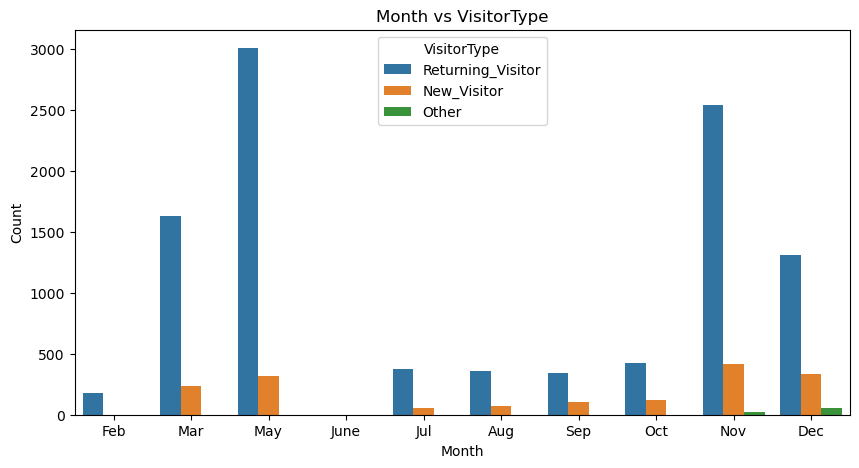

In [107]:
display(pd.crosstab(df['Month'], df['VisitorType']))

month_order  = ["Feb","Mar","May","June","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.figure(figsize=(10,5))
sns.countplot(
    x='Month',
    hue='VisitorType',
    data=df,
    order=month_order
)
plt.title('Month vs VisitorType')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

## <b>Categorical Variables vs Revenue Analysis</b>

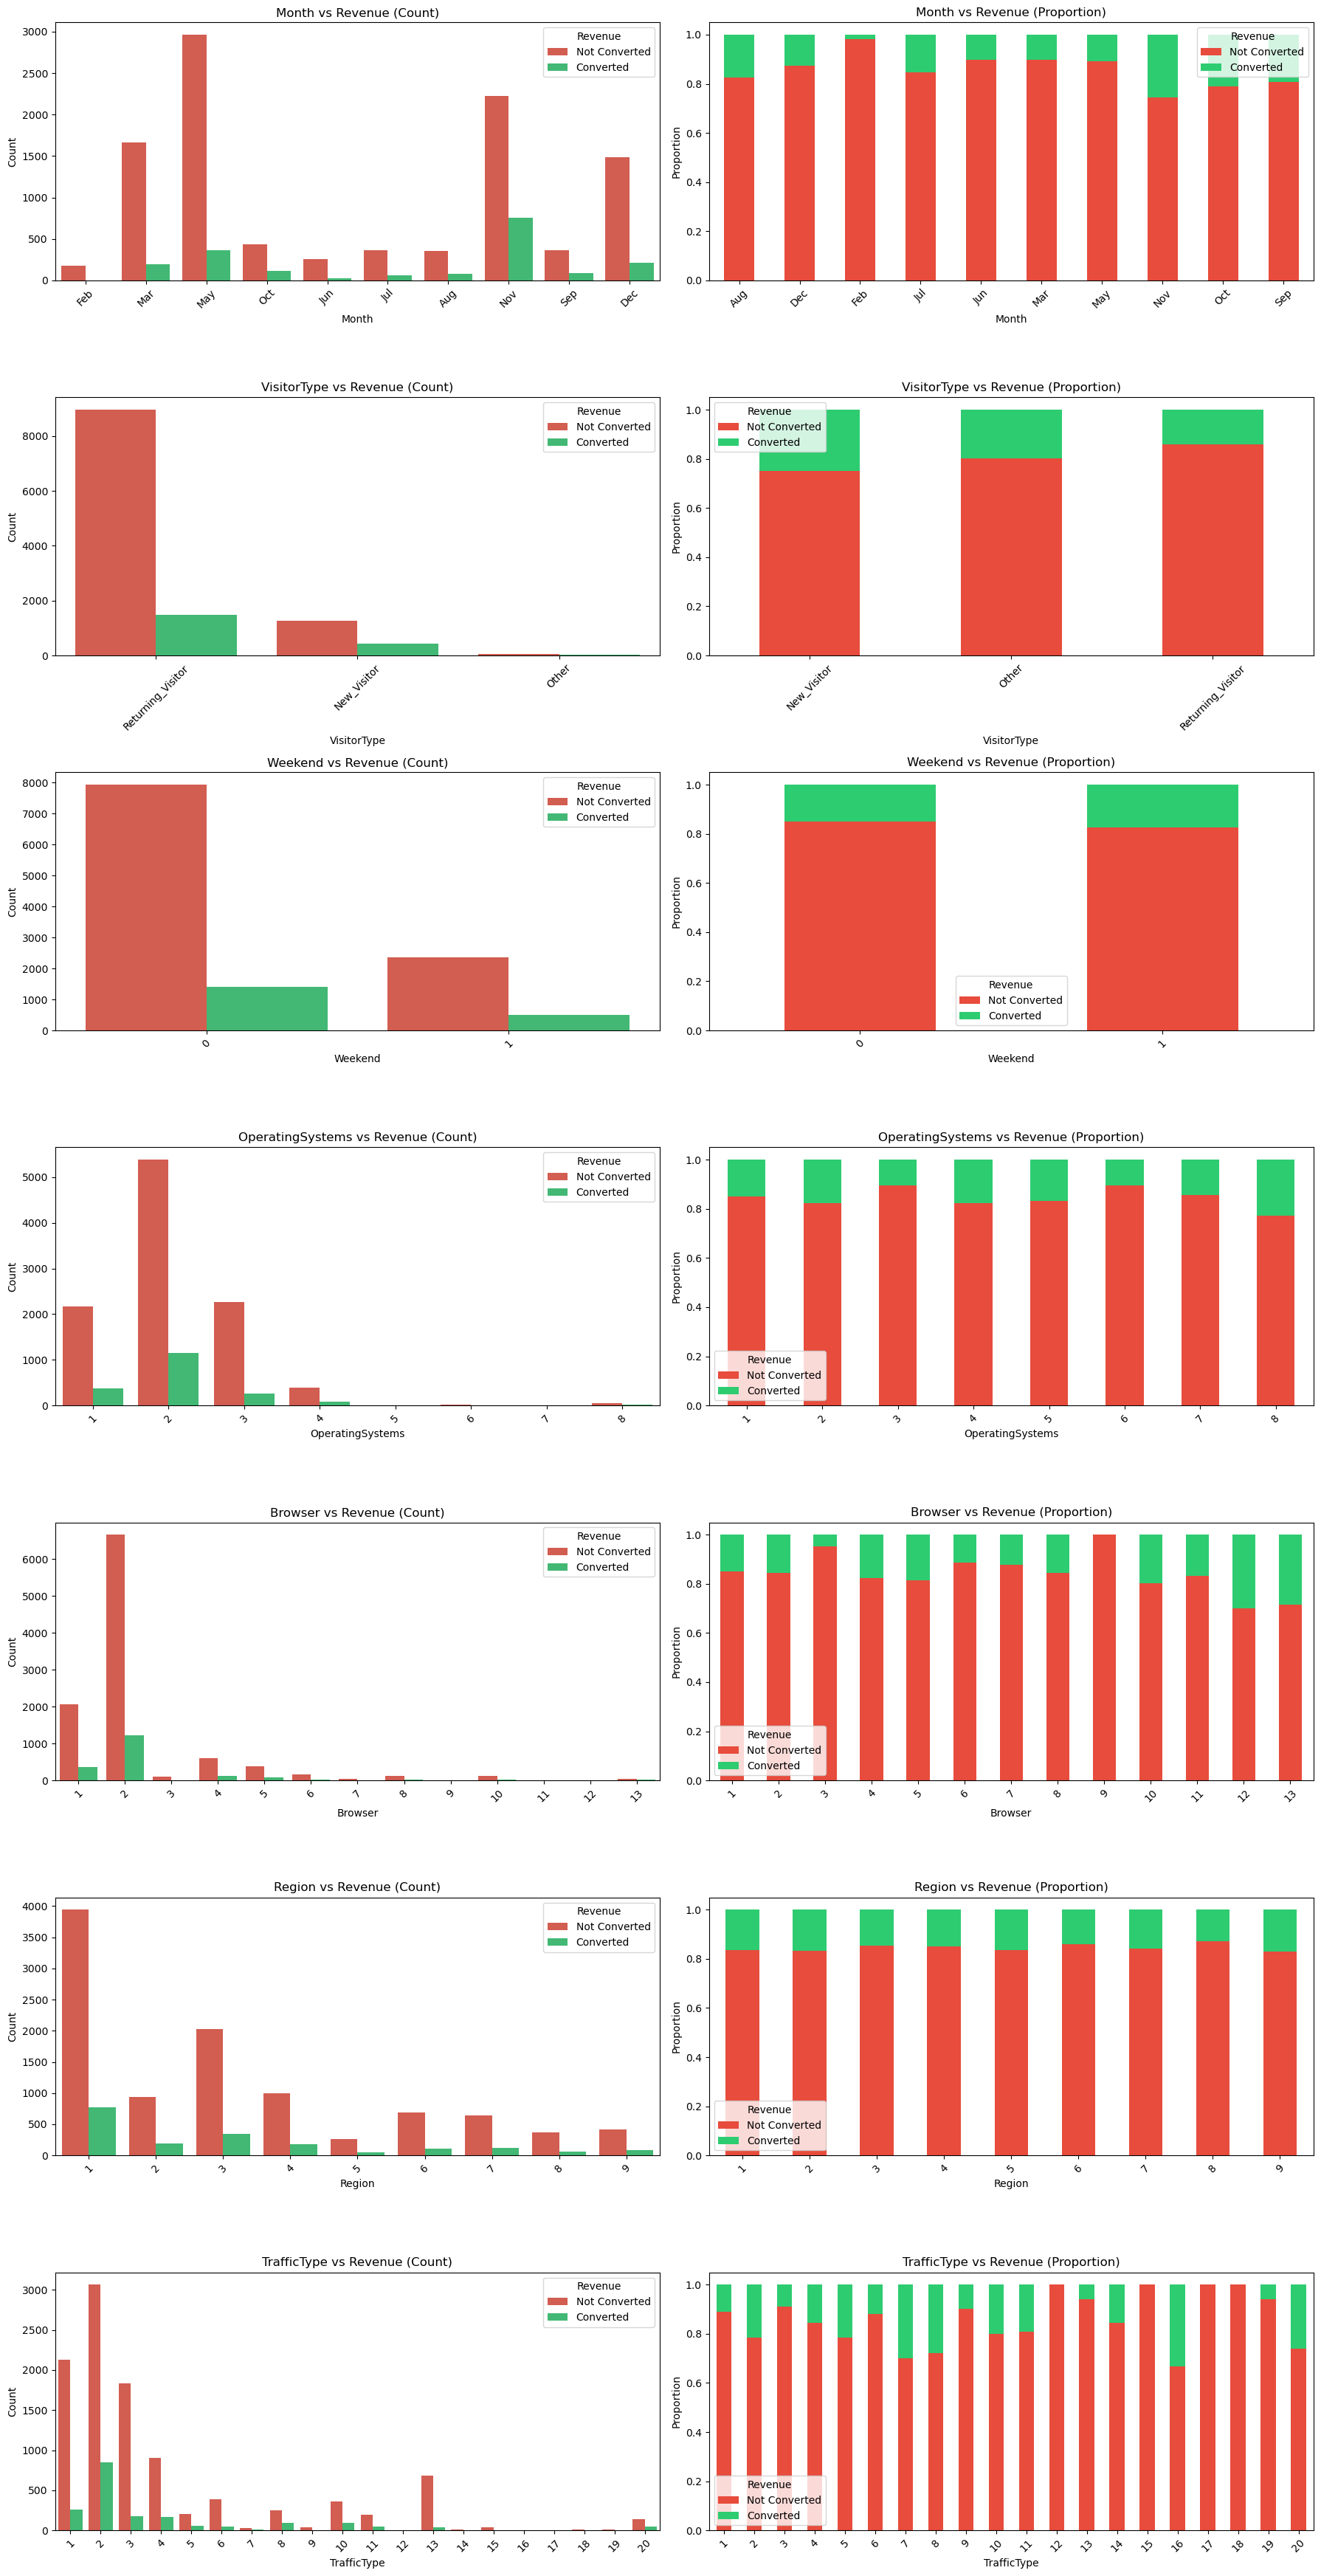

In [108]:
fig, axes = plt.subplots(len(cat_columns), 2, figsize=(18, len(cat_columns) * 5))

for i, col in enumerate(cat_columns):
    
    # Countplot
    sns.countplot(data=df, x=col, hue="Revenue", 
                  palette={0:"#E74C3C", 1:"#2ECC71"}, 
                  ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} vs Revenue (Count)")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")
    axes[i, 0].legend(title="Revenue", labels=["Not Converted", "Converted"])
    axes[i, 0].tick_params(axis="x", rotation=45)

    # Stacked Bar
    pd.crosstab(df[col], df["Revenue"], normalize="index").plot(
        kind="bar", 
        stacked=True, 
        color=["#E74C3C","#2ECC71"],
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{col} vs Revenue (Proportion)")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Proportion")
    axes[i, 1].legend(title="Revenue", labels=["Not Converted", "Converted"])
    axes[i, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## <b>Conversion Rate Analysis</b>

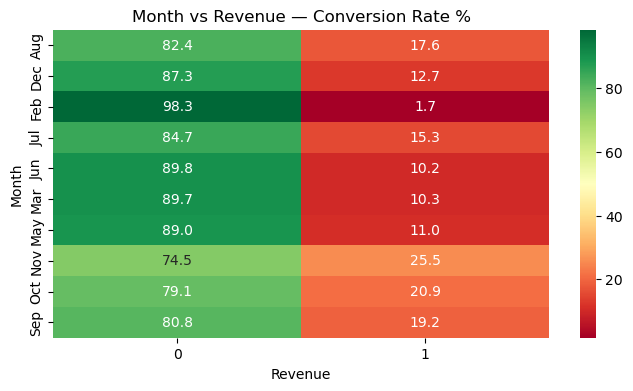

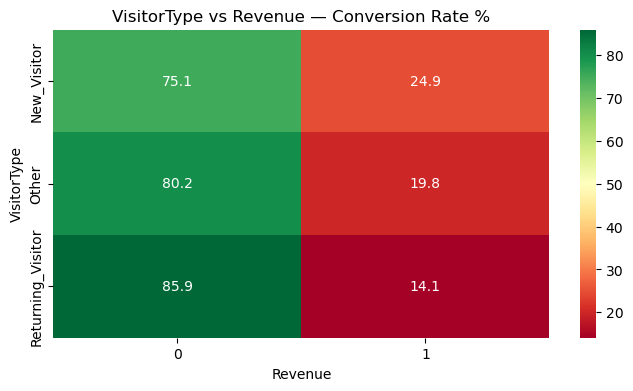

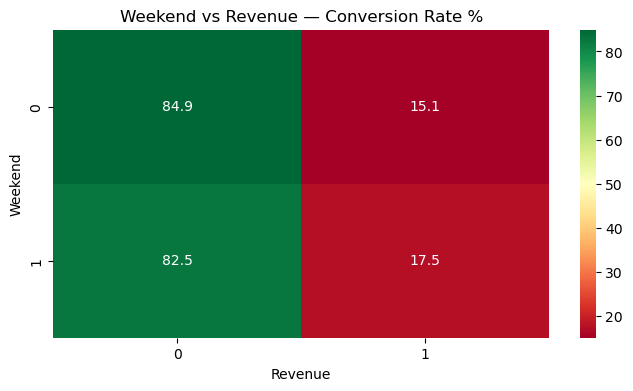

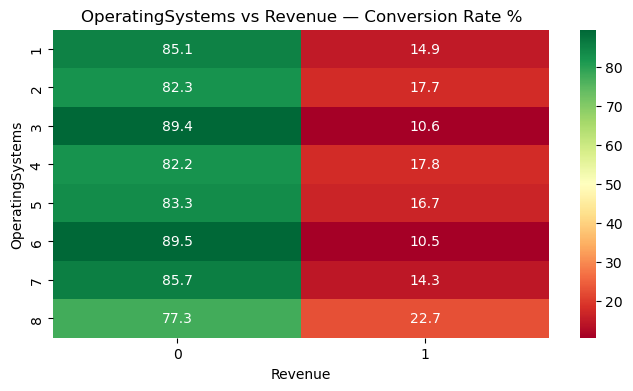

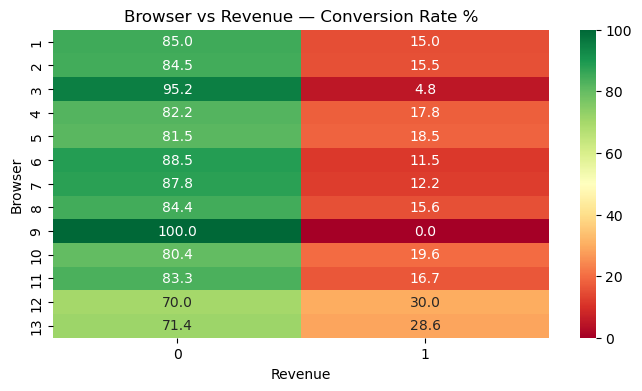

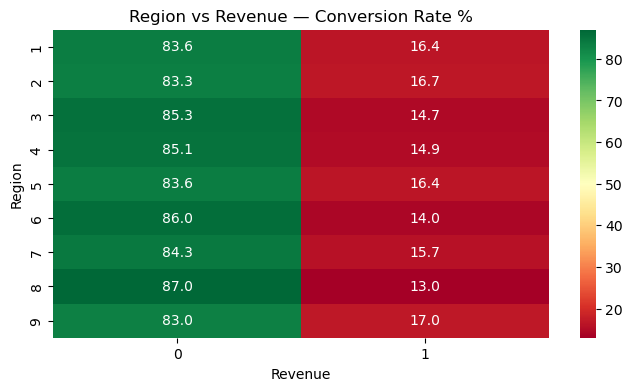

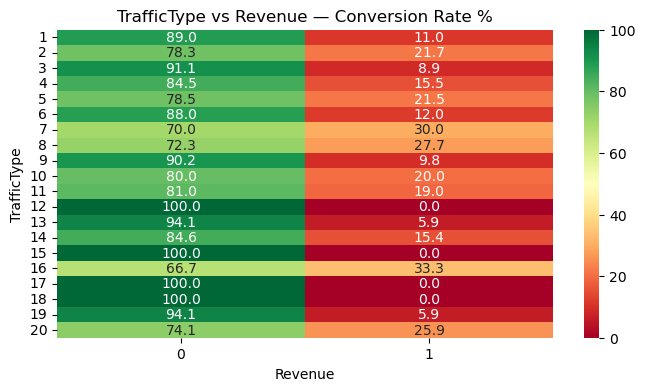

In [109]:
for col in cat_columns:
    plt.figure(figsize=(8, 4))
    ct = pd.crosstab(df[col], df["Revenue"], normalize="index")*100 
    sns.heatmap(ct, annot=True, fmt=".1f", cmap="RdYlGn")
    plt.title(f"{col} vs Revenue — Conversion Rate %")
    plt.show()

# <u><b> NUM-CAT ANALYSIS</u></b>

## <u><b>PageValues vs Month<u><b>

In [110]:
df.groupby('Month').agg({'PageValues': ["mean", "min", "max", "std", "count"]})

PageValues                                 
            mean     min       max      std count
Month                                            
Aug      5.93807 0.00000 153.57770 15.94990   433
Dec      6.91736 0.00000 360.95338 23.06820  1706
Feb      0.90512 0.00000  54.17976  5.57594   181
Jul      4.10441 0.00000  79.44353 11.02579   432
Jun      3.42714 0.00000 166.37355 12.93646   285
Mar      4.05974 0.00000 261.49129 14.46470  1860
May      5.48868 0.00000 254.60716 16.69064  3329
Nov      7.16763 0.00000 361.76374 21.00122  2982
Oct      8.64558 0.00000 246.75859 21.50856   549
Sep      7.55683 0.00000 258.54987 21.82993   448

## <u><b>BounceRates vs VisitorType<u><b>

In [111]:
df.groupby('VisitorType').agg({'BounceRates': ["mean", "min", "max", "std", "count"]})

BounceRates                               
                         mean     min     max     std  count
VisitorType                                                 
New_Visitor           0.00515 0.00000 0.20000 0.02589   1693
Other                 0.03058 0.00000 0.20000 0.07136     81
Returning_Visitor     0.02276 0.00000 0.20000 0.04695  10431

## <u><b>ProductRelated_Duration vs VisitorType<u><b>

In [112]:
df.groupby('VisitorType').agg({'ProductRelated_Duration': ["mean", "min", "max", "std", "count"]})

ProductRelated_Duration                                 \
                                     mean     min         max        std   
VisitorType                                                                
New_Visitor                     636.76925 0.00000 12983.78771  766.40707   
Other                           598.57300 0.00000  9630.20952 1288.76458   
Returning_Visitor              1304.25521 0.00000 63973.52223 2034.32387   

                          
                   count  
VisitorType               
New_Visitor         1693  
Other                 81  
Returning_Visitor  10431

## <b><u>KEY FINDING SUMMARY<b><u>

- **Only 15.63% of visitors actually buy.**
Out of 12,205 cleaned sessions, only 1,908 resulted in a purchase. 84.37% of visitors browse and leave without buying.

- **Buyers spend 73% more time on product pages.**
Non-buyers averaged 1,083 seconds on product pages. Buyers averaged 1,876 seconds. The more time a user spends on products, the more likely they are to purchase.

- **November is the best month (25.49%), February is the worst (1.66%).**
That is a 15x difference. The business is heavily dependent on a short Nov–Oct festive window. Feb, Mar, Jun are very weak months.

- **New visitors convert at 24.9% vs returning visitors at only 14.1%.**
Returning visitors make up 85.5% of all traffic but convert far less. New visitors convert nearly 2x better despite being only 13.9% of traffic — a clear re-engagement gap.

- **Buyers have 4.5x lower bounce rates than non-buyers.**
Non-buyers: 0.023 avg bounce rate. Buyers: 0.005. Traffic Types 15, 17, 18, and 12 have the highest bounce rates and literally 0% conversion — pure wasted traffic.

- **PageValues of buyers are 13.6x higher than non-buyers.**
Non-buyers averaged PageValue of 2.0. Buyers averaged 27.26. This is the single biggest gap between buyers and non-buyers in the entire dataset — high PageValue pages are where purchases happen.


# <b><u>PREPROCESSING<b><u>

### <b><u>Outlier Detection<b><u>
Outliers are data points that lie significantly far from the majority of observations in a dataset.

In [113]:
df[num_columns].describe( percentiles=[.1,.2,.25,.5,.75, .9, .95, .96, .97, .98,.99]).T

,count,mean,std,min,10%,20%,25%,50%,75%,90%,95%,96%,97%,98%,99%,max
Administrative,12205.00000,2.33888,3.33044,0.00000,0.00000,0.00000,0.00000,1.00000,4.00000,7.00000,9.00000,10.00000,11.00000,12.00000,14.00000,27.00000
Administrative_Duration,12205.00000,81.64633,177.49185,0.00000,0.00000,0.00000,0.00000,9.00000,94.70000,227.00000,352.20810,399.67000,473.96400,598.34500,838.70489,3398.75000
Informational,12205.00000,0.50873,1.27562,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2.00000,3.00000,3.00000,4.00000,5.00000,6.00000,24.00000
Informational_Duration,12205.00000,34.82545,141.42481,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,73.90000,199.00000,246.75200,314.88000,435.17400,722.37920,2549.37500
ProductRelated,12205.00000,32.04564,44.59365,0.00000,3.00000,6.00000,8.00000,18.00000,38.00000,74.00000,110.00000,122.00000,139.00000,162.00000,221.00000,705.00000
ProductRelated_Duration,12205.00000,1206.98246,1919.60140,0.00000,44.50000,137.00000,193.00000,608.94286,1477.15476,2904.45914,4312.95628,4873.96913,5518.92060,6724.21379,8704.27157,63973.52223
BounceRates,12205.00000,0.02037,0.04526,0.00000,0.00000,0.00000,0.00000,0.00290,0.01667,0.05000,0.14933,0.20000,0.20000,0.20000,0.20000,0.20000
ExitRates,12205.00000,0.04147,0.04616,0.00000,0.00741,0.01196,0.01423,0.02500,0.04853,0.10000,0.17371,0.20000,0.20000,0.20000,0.20000,0.20000
PageValues,12205.00000,5.94957,18.65367,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,19.11414,38.30146,44.73587,53.25215,62.86498,86.10869,361.76374
SpecialDay,12205.00000,0.06194,0.19967,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.20000,0.60000,0.60000,0.80000,0.80000,1.00000,1.00000


### <b><u>Outlier Counts<b><u>

In [114]:
outlier_counts = {}
outlier_cols = ["Administrative",
    "Administrative_Duration",
    "Informational",          
    "Informational_Duration",
    "ProductRelated",       
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    'TotalDuration',
    "TotalPages" ]
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_counts[col] = len(outliers)

# Convert to DataFrame for better view
outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier_Count'])
outlier_df.sort_values(by='Outlier_Count', ascending=False)

,Outlier_Count
PageValues,2730
Informational,2631
Informational_Duration,2405
BounceRates,1428
ExitRates,1325
Administrative_Duration,1149
ProductRelated,1007
TotalPages,971
ProductRelated_Duration,951
TotalDuration,922


### <b><u>Visualize Outlier Counts<b><u>

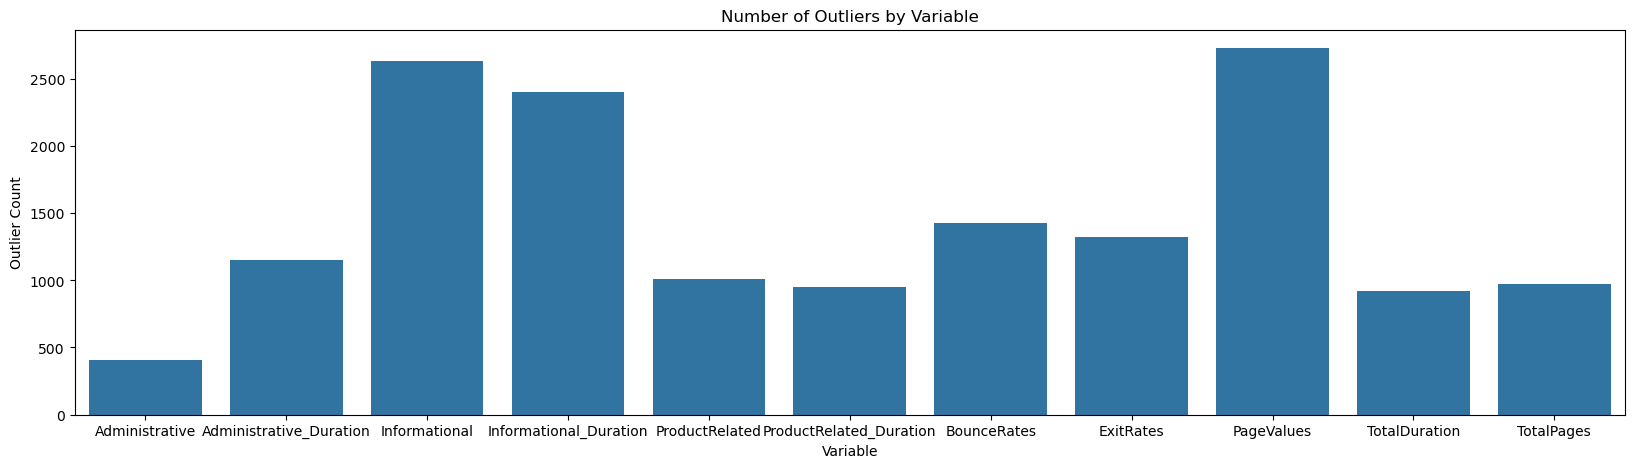

In [115]:
plt.figure(figsize=(20,5))
sns.barplot(x=outlier_df.index, y=outlier_df['Outlier_Count'])
plt.title("Number of Outliers by Variable")
plt.xlabel("Variable")
plt.ylabel("Outlier Count")
plt.show()

### <b><u>Boxplot for Outlier Analysis<b><u>

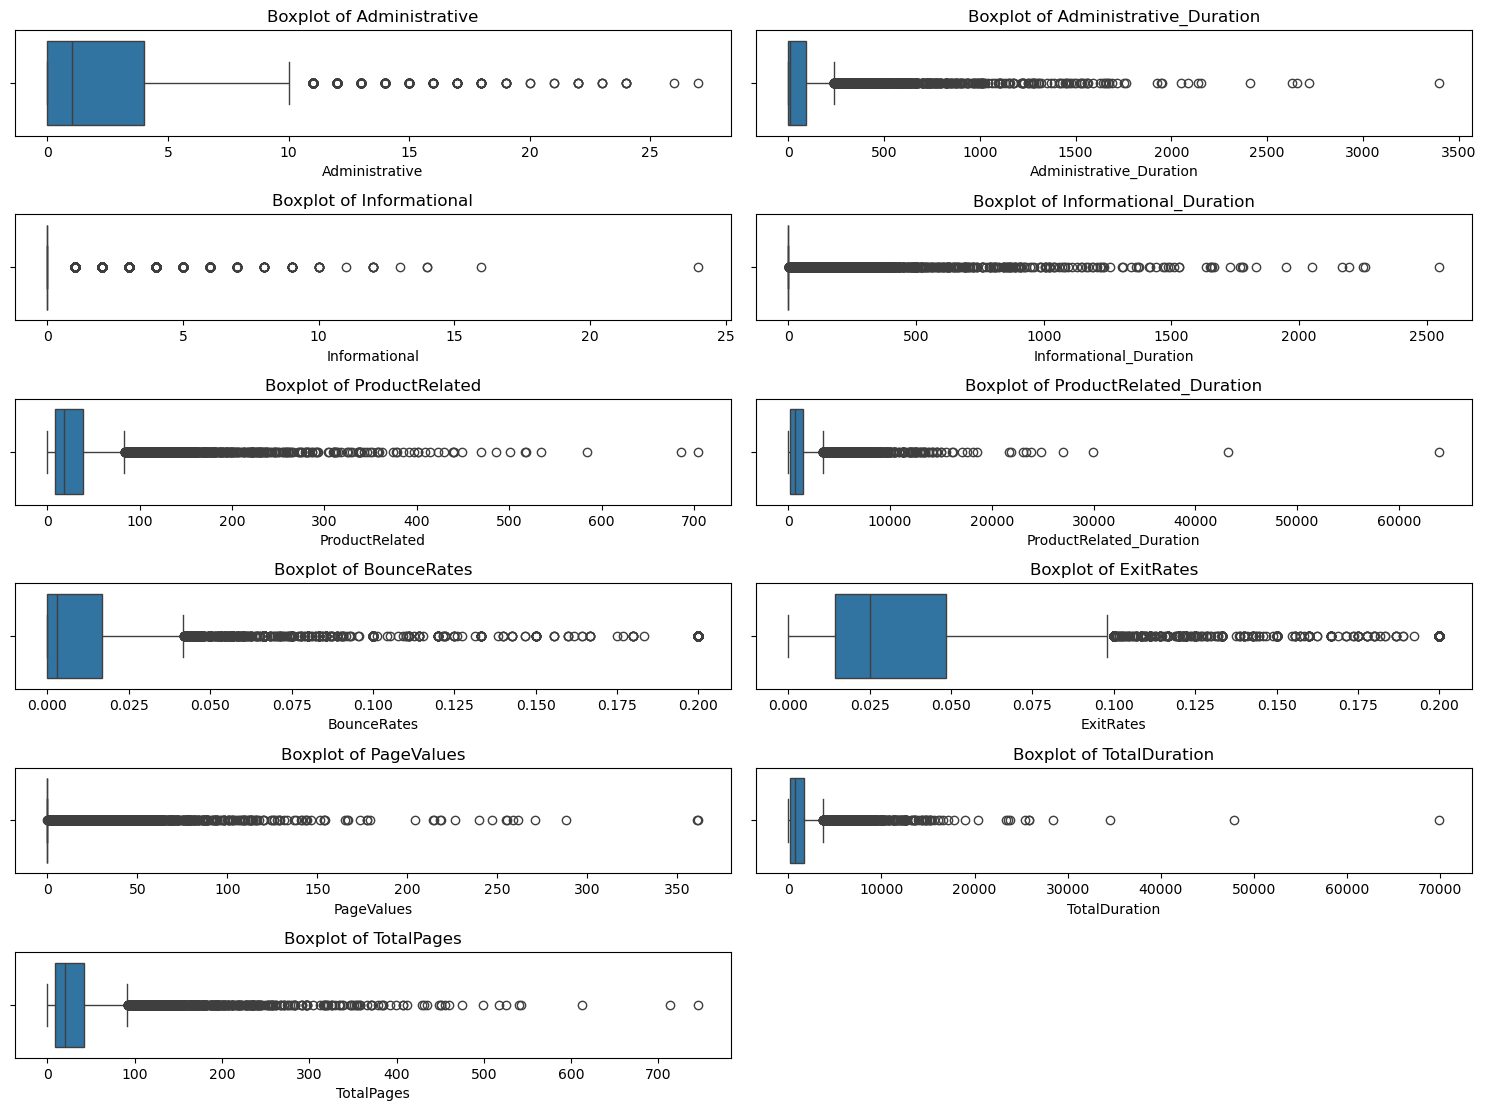

In [116]:
plt.figure(figsize=(15,20))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(len(outlier_cols), 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

## <span style="color:darkblue"> Why Outliers Exist in the Dataset </span>

- <b>Administrative & Administrative_Duration</b> — Some users visited many account or administrative pages repeatedly, such as checking order history, updating account settings, or navigating multiple admin-related pages.

- <b>Informational & Informational_Duration</b> — Most users visited very few informational pages, while a smaller group explored FAQ, policy, and informational sections extensively, creating high variation in the data.

- <b>ProductRelated & ProductRelated_Duration</b> — Certain users browsed a very large number of product pages and spent unusually high time exploring products due to comparison shopping, purchase research, or inactive browser sessions left open.

- <b>BounceRates</b> — High bounce rate outliers occurred because some users left the website immediately after landing on a page, possibly due to irrelevant traffic, accidental clicks, or poor landing page relevance.

- <b>ExitRates</b> — High exit rate outliers indicate sessions where users exited from specific pages, such as checkout abandonment or product comparison behavior before leaving the website.

- <b>PageValues</b> — High PageValue outliers were generated by a smaller group of highly valuable customers who interacted with expensive or high-converting product pages.

In [117]:
import pandas as pd

df = pd.get_dummies(
    df,
    columns=["Month", "VisitorType"],
    drop_first=True,
    dtype=int
)

In [118]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

In [119]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [120]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [121]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [122]:
lr.score(X_train_scaled, y_train)           #training accuracy

0.8828349037279803

In [123]:
lr.score(X_test_scaled, y_test)           #test accuracy

0.889389594428513

In [124]:
pred_train=lr.predict(X_train_scaled)
pred_test=lr.predict(X_test_scaled)

In [125]:
from sklearn import metrics
pd.DataFrame(metrics.confusion_matrix(y_train, pred_train), 
             index=["act0", "act1"], columns=["pred0", "pred1"])

,pred0,pred1
act0,8043,195
act1,949,577


In [126]:
pd.DataFrame(metrics.confusion_matrix(y_test, pred_test), 
             index=["act0", "act1"], columns=["pred0", "pred1"])

,pred0,pred1
act0,2012,47
act1,223,159


In [127]:
print(metrics.classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      8238
           1       0.75      0.38      0.50      1526

    accuracy                           0.88      9764
   macro avg       0.82      0.68      0.72      9764
weighted avg       0.87      0.88      0.87      9764



In [128]:
print(metrics.classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2059
           1       0.77      0.42      0.54       382

    accuracy                           0.89      2441
   macro avg       0.84      0.70      0.74      2441
weighted avg       0.88      0.89      0.88      2441



In [129]:
# Getting prob for train data and test data
train_prob=lr.predict_proba(X_train_scaled)[:,1]
test_prob=lr.predict_proba(X_test_scaled)[:,1]

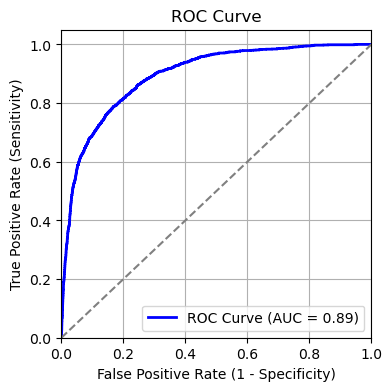

AUC Score: 0.8944


In [130]:
fpr, tpr, threshold = metrics.roc_curve(y_train, train_prob)
roc_auc = metrics.auc(fpr, tpr)  # Compute AUC - area under the curve

plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line for random model
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print AUC Score
print(f'AUC Score: {roc_auc:.4f}')


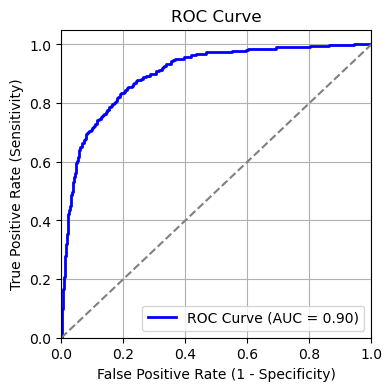

AUC Score: 0.9022


In [131]:
fpr, tpr, threshold = metrics.roc_curve(y_test, test_prob)
roc_auc = metrics.auc(fpr, tpr)  # Compute AUC - area under the curve

plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line for random model
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print AUC Score
print(f'AUC Score: {roc_auc:.4f}')


In [132]:
from sklearn.metrics import roc_auc_score

train_prob = lr.predict_proba(X_train_scaled)[:,1]
test_prob = lr.predict_proba(X_test_scaled)[:,1]

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, test_prob)

print("Train ROC-AUC:", train_auc)
print("Test ROC-AUC:", test_auc)

Train ROC-AUC: 0.8943765696607193
Test ROC-AUC: 0.9021636589713401
